In [1]:
import json

import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import scienceplots
import seaborn as sns
from matplotlib.patches import ConnectionPatch
from matplotlib.ticker import FuncFormatter

from qr.utils import *

sns.set_style("whitegrid")
plt.style.use(["science", "grid", "no-latex"])

In [2]:
ticker = "PFE"
df, df_emp = load_data(ticker)

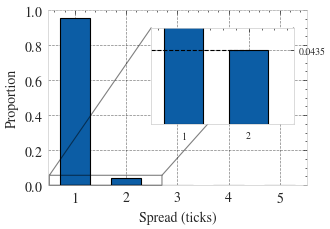

In [16]:
with transparent():
    spread_dist = (
        df_emp.filter(pl.col("event").eq("Trade"))
        .select(pl.col("spread").value_counts(normalize=True))
        .unnest("spread")
        .sort("spread")
        .filter(pl.col("spread") <= 5)
    )
    spreads = spread_dist["spread"].to_numpy()
    props = spread_dist["proportion"].to_numpy()
    val_2 = props[spreads == 2][0]
    
    fig, ax = plt.subplots(figsize=(3.5, 2.5))
    ax.bar(spreads, props, width=0.6, edgecolor="k", linewidth=0.8)
    ax.set_xticks(spreads)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Spread (ticks)")
    ax.set_ylabel("Proportion")
    
    # Inset zoom
    axins = ax.inset_axes([0.4, 0.35, 0.55, 0.55])
    axins.bar(spreads, props, width=0.6, edgecolor="k", linewidth=0.8)
    axins.set_xlim(0.5, 2.7)
    axins.set_ylim(0, val_2 * 1.3)
    axins.set_xticks([1, 2])
    axins.hlines(val_2, axins.get_xlim()[0], 2, linestyles="--", colors="k", linewidth=0.8)
    axins.set_yticks([val_2])
    axins.yaxis.tick_right()
    axins.set_yticklabels([f"{val_2:.4f}"], fontsize=16)
    axins.tick_params(labelsize=7)
    
    # Connect zoom region to inset
    ax.indicate_inset_zoom(axins, edgecolor="k", linewidth=0.8)
    fig.patch.set_alpha(0)
    ax.set_facecolor("white")
    fig.tight_layout()
    plt.show()
    fig.savefig(
        "../../paper/spread_before_trades_pfe.pdf", bbox_inches="tight", transparent=True
    )

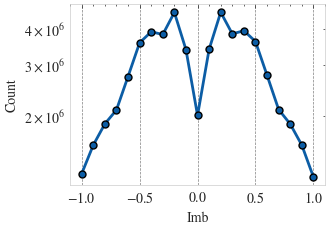

In [20]:
with transparent():
    count = df.group_by("imbalance").agg(pl.col("len").sum()).sort("imbalance")
    fig, ax = plt.subplots(figsize=(3.5, 2.5))
    ax.plot(
        count["imbalance"],
        count["len"],
        marker="o",
        mec="k",
        ms=5,
        lw=2,
    )
    ax.set_xlabel("Imb")
    ax.set_ylabel("Count")
    ax.ticklabel_format(style="scientific", axis="y", scilimits=(0, 0))
    ax.set_yscale("log")
    ax.set_xticks([-1, -0.5, 0, 0.5, 1])
    fig.patch.set_alpha(0)
    ax.set_facecolor("white")
    fig.tight_layout()
    plt.show()
    fig.savefig("../../paper/imb_count_PFE.pdf", bbox_inches="tight")

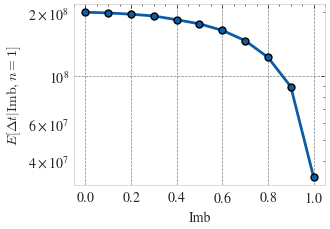

In [21]:
with transparent():
    delta_t = est.exp_delta_t(df.lazy())
    fig, ax = plt.subplots(figsize=(3.5, 2.5))
    ax.plot(
        delta_t.filter(pl.col("spread").eq(1))["imbalance"],
        delta_t.filter(pl.col("spread").eq(1))["average_dt"],
        marker="o",
        mec="k",
        ms=5,
        lw=2,
    )
    ax.set_xlabel("Imb")
    ax.set_ylabel(r"$E[\Delta t | \text{Imb}, n=1]$")
    ax.ticklabel_format(style="scientific", axis="y", scilimits=(0, 0))
    ax.set_yscale("log")
    fig.patch.set_alpha(0)
    ax.set_facecolor("white")
    fig.tight_layout()
    plt.show()
    fig.savefig("../../paper/avg_delta_t_PFE.pdf", bbox_inches="tight")

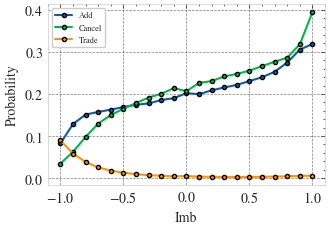

In [19]:
probabilities = pl.read_csv(f"../../data/{ticker}/qr_params/event_probabilities.csv")
probs = pl.concat(
    [
        probabilities.filter(pl.col("imbalance").ne(0)).with_columns(
            imbalance=-pl.col("imbalance"),
            side=-pl.col("side"),
            queue=-pl.col("queue"),
            event=pl.col("event").replace(
                {"Create_Ask": "Create_Bid", "Create_Bid": "Create_Ask"}
            ),
        ),
        probabilities,
    ]
).sort("imbalance", "spread", "event", "queue")
with transparent():
    fig, ax = plt.subplots(figsize=(3.5, 2.5))
    
    sub = probs.filter(pl.col("spread").eq(1) & pl.col("queue").eq(-1))
    for event in ["Add", "Cancel", "Trade"]:
        data = sub.filter(pl.col("event").eq(event)).sort("imbalance")
        ax.plot(
            data["imbalance"],
            data["probability"],
            marker="o",
            ms=3,
            lw=1.5,
            label=event,
            mec="k",
        )
    
    ax.set_xlabel("Imb")
    ax.set_ylabel("Probability")
    ax.legend(fontsize=6)
    fig.patch.set_alpha(0)
    ax.set_facecolor("white")
    fig.tight_layout()
    plt.show()
    fig.savefig(
        "../../paper/event_probabilities_spread_1_bid_PFE.pdf",
        bbox_inches="tight",
    )
    plt.show()